# Я художник, я так вижу, визуализация данных в питоне

# I. Numpy

### Импортируйте NumPy

In [2]:
from email.policy import default

import numpy as np

### Создайте одномерный массив размера 10, заполненный нулями и пятым элемент равным 1. Трансформируйте в двумерный массив.

In [12]:
test_array = np.zeros(10,dtype=int)
test_array[4] = 1
test_array

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

### Создайте одномерный массив со значениями от 10 до 49 и разверните его (первый элемент становится последним). Найдите в нем все четные элементы.

In [22]:
# сразу развернуть
d1_array = np.arange(49,9,-1)
d1_array

array([49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33,
       32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16,
       15, 14, 13, 12, 11, 10])

In [25]:
d1_array = np.arange(10,50)
d1_array = np.flip(d1_array)
d1_array

array([49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33,
       32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16,
       15, 14, 13, 12, 11, 10])

### Создайте двумерный массив 3x3 со значениями от 0 до 8

In [37]:
d2_array = np.random.randint(0,9,size=(3,3))
d2_array

array([[[5, 1],
        [7, 3]],

       [[6, 0],
        [1, 4]],

       [[3, 1],
        [5, 4]]], dtype=int32)

### Создайте массив 4x3x2 со случайными значениями. Найти его минимум и максимум.

In [41]:
d2_array = np.random.randint(0,800,size=(4,3,2))
print(d2_array.max())
print(d2_array.min())

778
3


### Создайте два двумерных массива размерами 6x4 и 4x3 и произведите их матричное умножение. 

In [8]:
d2_array = np.random.randint(1,9,size=(6,4))
d2_2_array = np.random.randint(1,9,size=(4,3))
result = np.dot(d2_array,d2_2_array)
result

array([[ 98, 131, 136],
       [138, 113, 148],
       [ 54,  71,  76],
       [ 65,  58,  78],
       [ 67,  66,  76],
       [ 77,  72,  92]], dtype=int32)

### Создайте случайный двумерный массив 7x7, найти у него среднее и стандартное оклонение. Нормализуйте этот массив.

In [10]:
# номализация $Xнорм = (Xi - Xсред)/Xоткл

d2_array = np.random.randint(10,92,size=(7,7))
mean_value  = d2_array.mean()
std_value = d2_array.std()
normalized_x = (d2_array - mean_value) / std_value
mean_value,std_value,normalized_x

(np.float64(49.95918367346939),
 np.float64(23.764970949520855),
 array([[-1.17648718,  0.08587498,  0.50666236,  0.29626867,  1.17992218,
          0.33834741,  0.59081984],
        [-0.33491241, -0.41906989, -0.25075493, -0.96609349,  0.88537101,
         -0.16659745,  0.25418993],
        [-1.3027234 ,  1.43239461, -0.20867619,  1.43239461,  1.72694578,
          0.67497732,  1.39031587],
        [ 0.80121353,  1.60070957,  1.51655209,  0.50666236, -1.68143204,
         -0.5453061 , -1.26064466],
        [ 0.96952849, -0.67154232,  0.71705606, -0.33491241,  1.05368596,
         -1.68143204,  0.5487411 ],
        [-0.41906989, -0.79777853, -1.42895961, -1.68143204, -0.46114862,
          0.08587498,  1.17992218],
        [-0.12451872, -1.42895961, -1.59727457,  0.46458362,  0.88537101,
         -1.00817223, -1.17648718]]))

# II. Pandas

### Импортируйте: pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

### Загрузите датасет Tips из набора датасетов seaborn

In [2]:
ds_tips = sns.load_dataset('tips')

### Посмотрите на первые 5 строчек

In [54]:
ds_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Узнайте сколько всего строчек и колонок в данных

In [15]:
# размерность (строки,колонки)
ds_tips.shape()

244

### Проверьте есть ли пропуски в данных

In [16]:
if ds_tips.isna().any().any() == False:
    print('пропусков нет')
else:#всего строк минус полностью заполненных
   print(f'кол-во строк с пропусками : {ds_tips.shape[0] - ~ds_tips.isna().any(axis=1)}')

пропусков нет


### Посмотрите на распределение числовых признаков

array([[<Axes: title={'center': 'total_bill'}>,
        <Axes: title={'center': 'tip'}>],
       [<Axes: title={'center': 'size'}>, <Axes: >]], dtype=object)

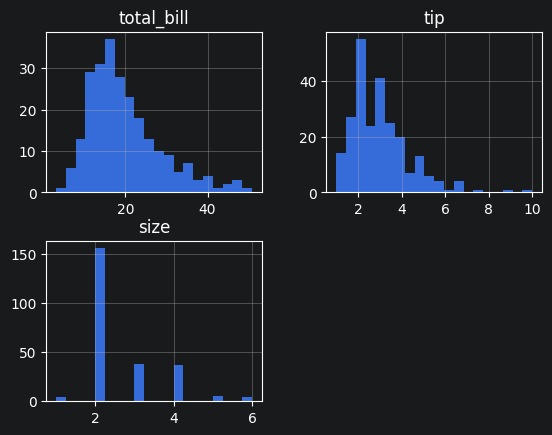

In [21]:
# поставим интервал 20
ds_tips.hist(bins=20)

### Найдите максимальное значение 'total_bill'

In [22]:
ds_tips['total_bill'].max()

np.float64(50.81)

### Найдите количество курящих людей

In [41]:
ds_tips[ds_tips['smoker']=='Yes'].shape[0]
#print((ds_tips['smoker']=='Yes').sum())

93

### Узнайте какой средний 'total_bill' в зависимости от 'day'

In [43]:
ds_tips.groupby('day')['total_bill'].std()

day
Thur    7.886170
Fri     8.302660
Sat     9.480419
Sun     8.832122
Name: total_bill, dtype: float64

### Отберите строчки с 'total_bill' больше медианы и узнайте какой средний 'tip' в зависимости от 'sex'

In [47]:
over_ds = ds_tips[ds_tips['total_bill'] > ds_tips['total_bill'].median()]
over_ds.groupby('sex')['tip'].mean()

sex
Male      3.756404
Female    3.663939
Name: tip, dtype: float64

### Преобразуйте признак 'smoker' в бинарный (0-No, 1-Yes)

In [65]:
ds_tips['smoker'] = ds_tips['smoker'].case_when([(ds_tips['smoker']=='Yes',1),(ds_tips['smoker']=='No',0)])
ds_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,0,Sun,Dinner,2
1,10.34,1.66,Male,0,Sun,Dinner,3
2,21.01,3.50,Male,0,Sun,Dinner,3
3,23.68,3.31,Male,0,Sun,Dinner,2
4,24.59,3.61,Female,0,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,0,Sat,Dinner,3
240,27.18,2.00,Female,1,Sat,Dinner,2
241,22.67,2.00,Male,1,Sat,Dinner,2
242,17.82,1.75,Male,0,Sat,Dinner,2


# III. Visualization

### Постройте гистограмму распределения признака 'total_bill'

<Axes: >

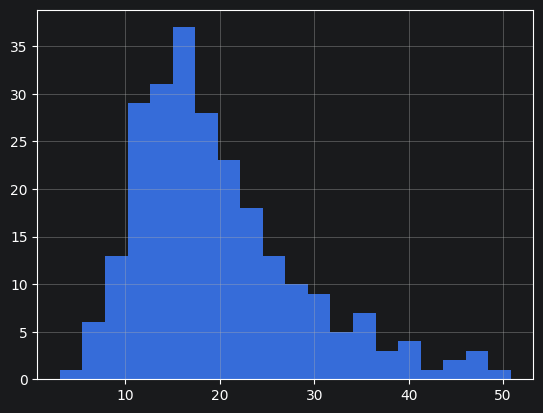

In [3]:
ds_tips['total_bill'].hist(bins=20)

### Постройте scatterplot, представляющий взаимосвязь между признаками 'total_bill' и 'tip'

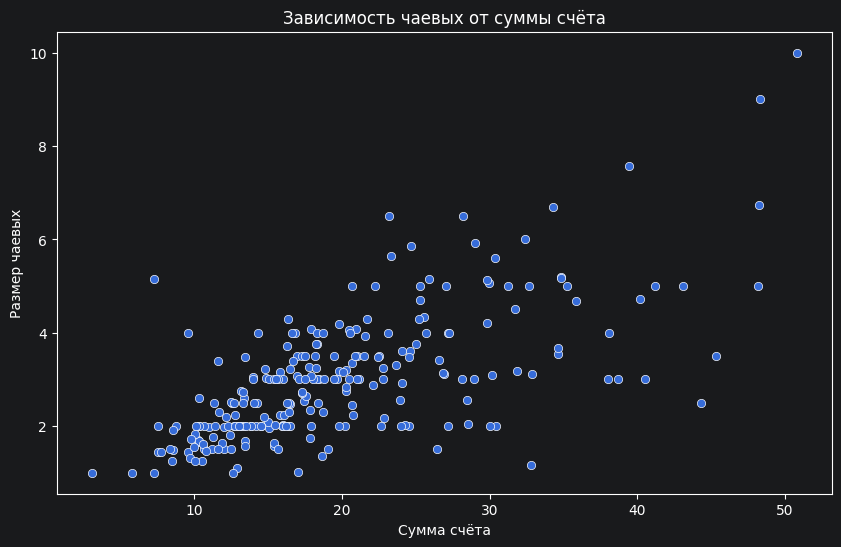

In [5]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
sns.scatterplot(x="total_bill", y="tip", data=ds_tips)
plt.title("Зависимость чаевых от суммы счёта")
plt.xlabel("Сумма счёта")
plt.ylabel("Размер чаевых")
plt.show()

### Постройте pairplot

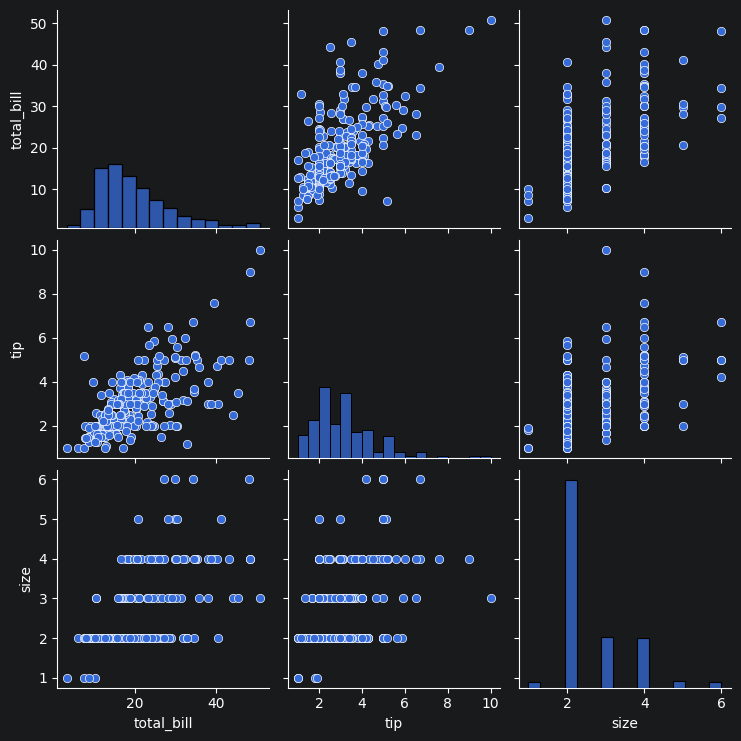

In [8]:
sns.pairplot(ds_tips)
plt.show()

### Постройте график взаимосвязи между признаками 'total_bill' и 'day'

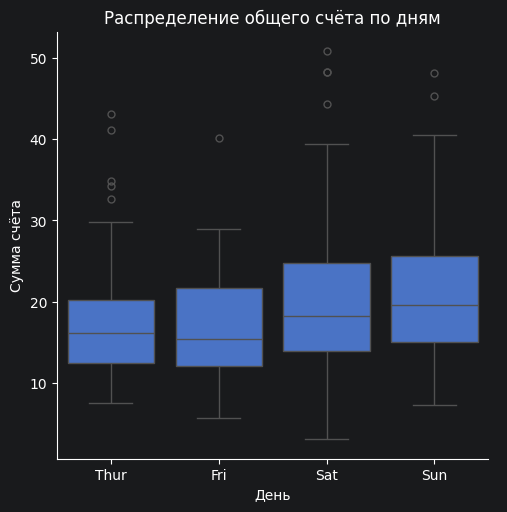

In [10]:
g = sns.catplot(
    data=ds_tips,
    x="day",  # ось X
    y="total_bill",  # ось Y
    kind="box"  #ящик с усами)
)

g.set_axis_labels("День", "Сумма счёта")
plt.title("Распределение общего счёта по дням")
plt.show()

### Постройте две гистограммы распределения признака 'tip' в зависимости от категорий 'time'

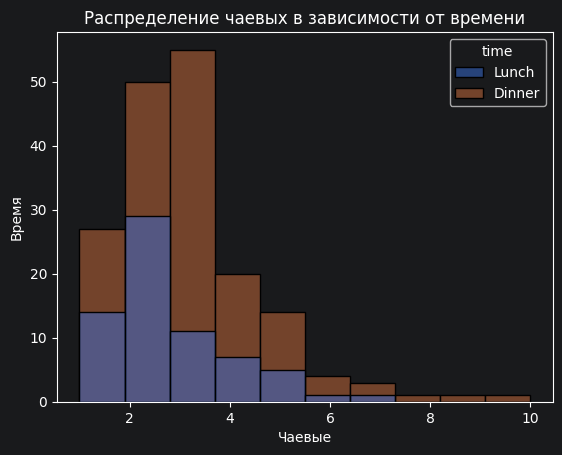

In [11]:
sns.histplot(data=ds_tips, x='tip', hue='time', bins=10)
plt.title('Распределение чаевых в зависимости от времени')
plt.xlabel('Чаевые')
plt.ylabel('Время')
plt.show()

### Постройте два графика scatterplot, представляющих взаимосвязь между признаками 'total_bill' и 'tip' один для Male, другой для Female и раскрасьте точки в зависимоти от признака 'smoker'

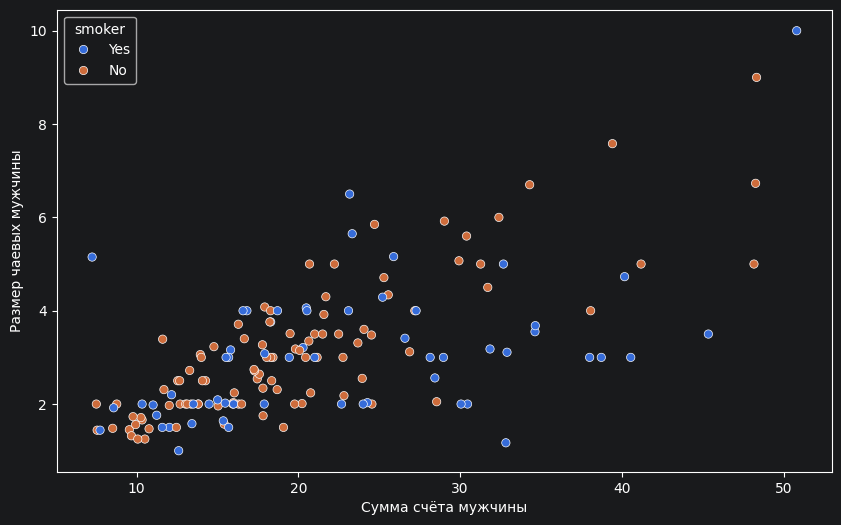

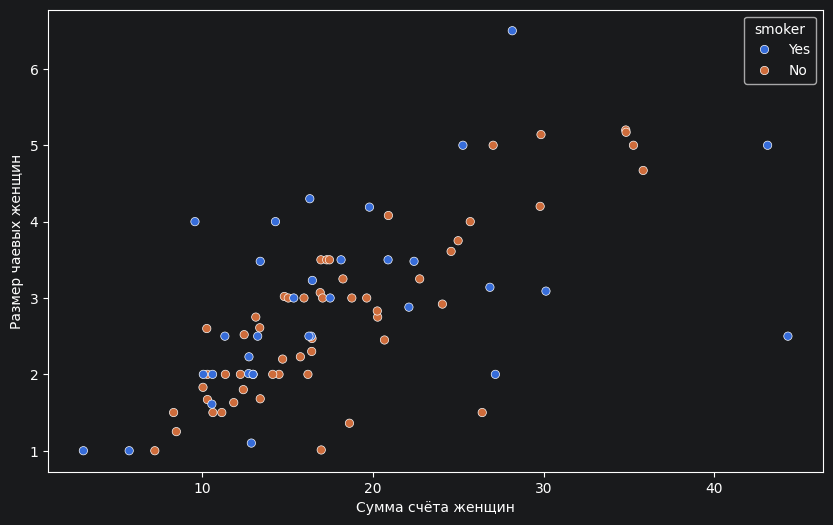

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="total_bill", y="tip",hue="smoker", data=ds_tips[ds_tips['sex']=='Male'])
plt.xlabel("Сумма счёта мужчины")
plt.ylabel("Размер чаевых мужчины")
plt.show()
plt.figure(figsize=(10, 6))
sns.scatterplot(x="total_bill", y="tip",hue="smoker", data=ds_tips[ds_tips['sex']=='Female'])
plt.xlabel("Сумма счёта женщин")
plt.ylabel("Размер чаевых женщин")
plt.show()

## Сделайте выводы по анализу датасета и построенным графикам. По желанию можете продолжить анализ данных и также отразить это в выводах.

In [ ]:
# Вывод по зависимостям величины чаевых от суммы счета. Чем больше счет тем больше чаевые в любых разрезах. Больше чаевых дают утром. Чаше всего чаевые дают в сумме от 10-15.